<a href="https://colab.research.google.com/github/spraveenmonu/spraveen_04/blob/main/Task_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

sentiment_data.csv not found -> generating a synthetic demo dataset instead.

Dataset shape: (420, 2)

Class distribution:
 sentiment
neutral     140
positive    140
negative    140
Name: count, dtype: int64


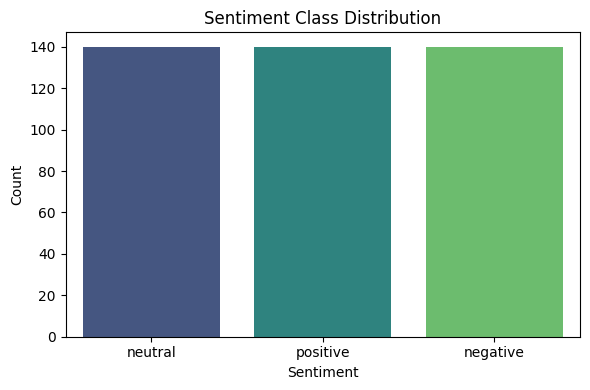


Sample of raw vs cleaned text:
                                                text  \
0         It is a standard phone, does what it says.   
1  I'm so happy with the delivery, excellent expe...   
2        It is a standard laptop, does what it says.   
3  I really enjoyed the software, top-notch quality.   
4             The game was delivered in a plain box.   

                                       clean_text  
0                              standard phone say  
1  im happy delivery excellent experience overall  
2                             standard laptop say  
3        really enjoyed software topnotch quality  
4                        game delivered plain box  

TF-IDF feature matrix shape: (420, 779)

Train size: 336, Test size: 84

===== Naive Bayes =====
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Detailed classification report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        28
     ne

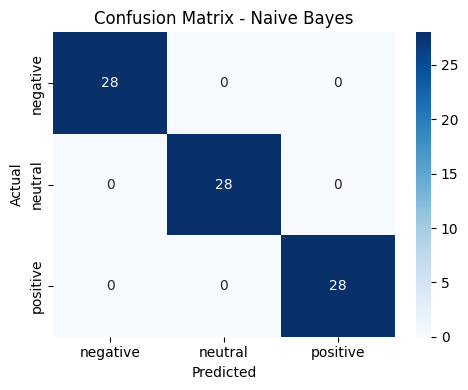


===== Logistic Regression =====
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Detailed classification report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        28
     neutral       1.00      1.00      1.00        28
    positive       1.00      1.00      1.00        28

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



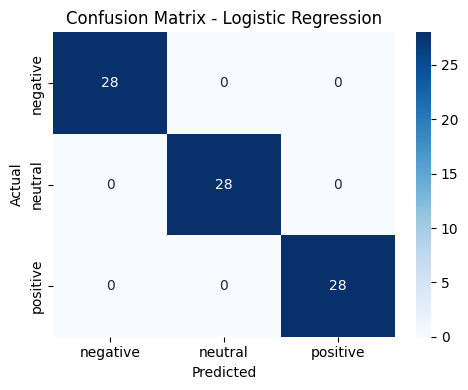

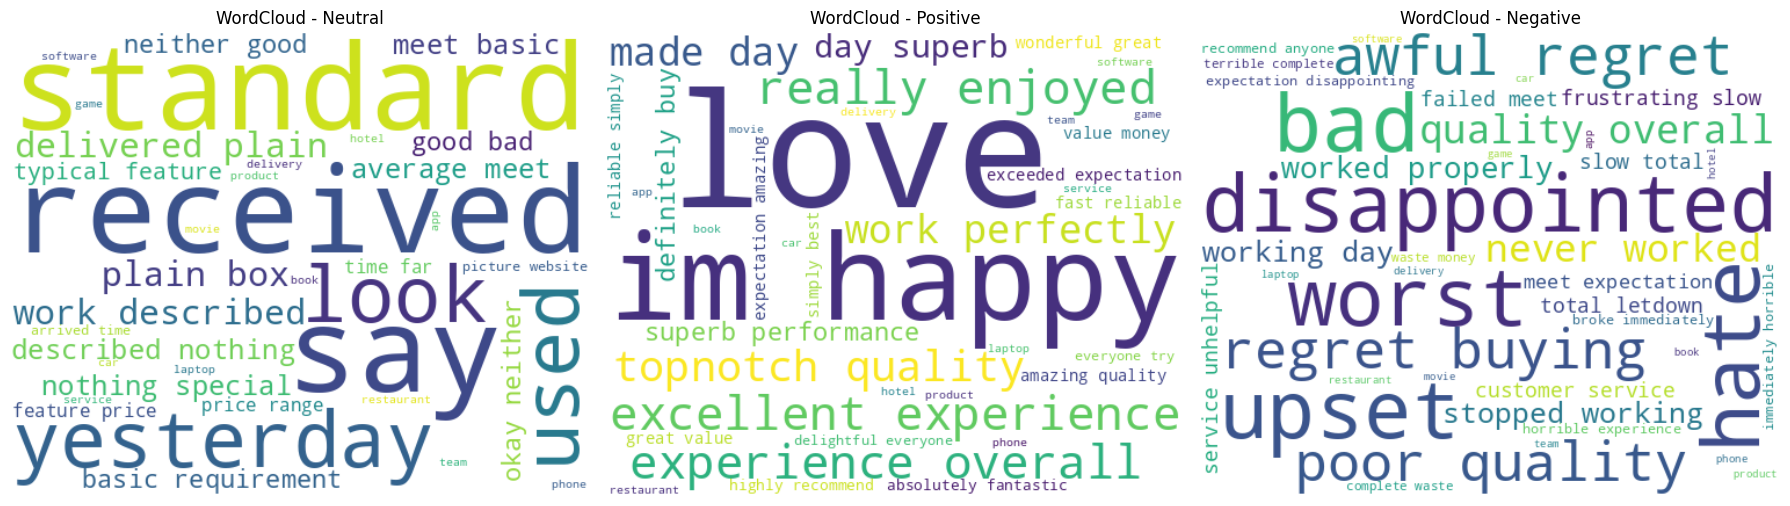


Total misclassified samples (Logistic Regression): 0 / 84

----- Sample Misclassifications & Discussion -----
No misclassifications found in the test set — model generalised very well on this data.

===================== CONCLUSION =====================
Naive Bayes           -> Accuracy: 1.0000, F1: 1.0000
Logistic Regression   -> Accuracy: 1.0000, F1: 1.0000

Best performing model: Logistic Regression

Discussion:
- Naive Bayes is fast, lightweight, and works well as a baseline for text
  classification, especially with smaller datasets, but assumes feature
  independence which can limit accuracy on nuanced text.
- Logistic Regression generally captures relationships between TF-IDF
  features more effectively and tends to perform better on sentiment
  tasks with richer vocabulary and more subtle distinctions between
  classes (e.g., negation, mixed sentiment).

Real-world applications:
- Monitoring social media / brand sentiment in real time.
- Analysing customer reviews (e-commerce,

In [ ]:
# ============================================================
# SENTIMENT ANALYSIS PIPELINE
# Positive / Negative / Neutral classification
# ============================================================

# ---- 0. IMPORTS ----
import re
import string
import random
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

# wordcloud is optional -> pip install wordcloud
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("Install 'wordcloud' package for word cloud visualisations: pip install wordcloud")

# Download necessary NLTK resources (only first run)
for pkg in ["punkt", "stopwords", "wordnet", "omw-1.4", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

random.seed(42)
np.random.seed(42)

# ============================================================
# 1. LOAD DATASET (synthetic demo data — replace with your own CSV)
#    Expected columns: 'text', 'sentiment' in {'positive','negative','neutral'}
# ============================================================
try:
    df = pd.read_csv("sentiment_data.csv")
    print("Loaded dataset from sentiment_data.csv")
except FileNotFoundError:
    print("sentiment_data.csv not found -> generating a synthetic demo dataset instead.")

    subjects = ["product", "service", "movie", "restaurant", "phone", "laptop",
                "book", "app", "hotel", "car", "team", "delivery", "software", "game"]

    positive_templates = [
        "I love the {}, it works perfectly!",
        "The {} exceeded my expectations, amazing quality.",
        "Absolutely fantastic {}, highly recommend it.",
        "This {} is wonderful and a great value for money.",
        "I'm so happy with the {}, excellent experience overall.",
        "The {} was delightful, everyone should try it.",
        "Great {}! Fast, reliable and simply the best.",
        "What an amazing {}, I will definitely buy again.",
        "The {} made my day, superb performance.",
        "I really enjoyed the {}, top-notch quality."
    ]
    negative_templates = [
        "I hate the {}, it stopped working after a day.",
        "The {} was terrible, complete waste of money.",
        "Very disappointed with the {}, poor quality overall.",
        "This {} is awful, I regret buying it.",
        "The {} broke down immediately, horrible experience.",
        "Worst {} ever, would not recommend to anyone.",
        "The {} was frustrating and slow, total letdown.",
        "I am upset about the {}, it never worked properly.",
        "Bad {}, customer service was unhelpful too.",
        "The {} failed to meet expectations, very disappointing."
    ]
    neutral_templates = [
        "The {} arrived on time.",
        "I received the {} yesterday.",
        "The {} works as described, nothing special.",
        "This {} is okay, neither good nor bad.",
        "The {} looks like the picture on the website.",
        "It is a standard {}, does what it says.",
        "The {} was delivered in a plain box.",
        "The {} has typical features for this price range.",
        "I used the {} a few times so far.",
        "The {} is average, meets basic requirements."
    ]

    rows = []
    for subj in subjects:
        for tmpl in positive_templates:
            rows.append((tmpl.format(subj), "positive"))
        for tmpl in negative_templates:
            rows.append((tmpl.format(subj), "negative"))
        for tmpl in neutral_templates:
            rows.append((tmpl.format(subj), "neutral"))

    df = pd.DataFrame(rows, columns=["text", "sentiment"])
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"\nDataset shape: {df.shape}")
df.head()

# ---- Class distribution ----
print("\nClass distribution:\n", df["sentiment"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x="sentiment", data=df, order=df["sentiment"].value_counts().index, palette="viridis")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ============================================================
# 2. TEXT PREPROCESSING PIPELINE
#    Steps: lowercase -> remove punctuation/numbers -> tokenize
#           -> remove stopwords -> lemmatize
# ============================================================
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()                                   # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)             # remove URLs
    text = re.sub(r"\d+", "", text)                        # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    tokens = word_tokenize(text)                            # tokenize
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]  # remove stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens]      # lemmatize
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess_text)
print("\nSample of raw vs cleaned text:")
print(df[["text", "clean_text"]].head())

# ============================================================
# 3. FEATURE EXTRACTION: TF-IDF
# ------------------------------------------------------------
# WHY TF-IDF?
# TF-IDF (Term Frequency - Inverse Document Frequency) converts text into
# numeric vectors by weighing each word based on:
#   - how frequently it appears in a document (TF)
#   - how rare/common it is across all documents (IDF)
# Words that are common across many documents (like "the", "is") get a
# lower weight, while words that are more unique/informative to a specific
# document get a higher weight. This helps the classifier focus on words
# that actually carry sentiment signal rather than generic filler words.
# ============================================================
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X = tfidf.fit_transform(df["clean_text"])
y = df["sentiment"]

print(f"\nTF-IDF feature matrix shape: {X.shape}")

# ============================================================
# 4. TRAIN/TEST SPLIT (80/20)
# ============================================================
X_train, X_test, y_train, y_test, text_train, text_test = train_test_split(
    X, y, df["text"], test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# ============================================================
# 5. TRAIN CLASSIFIERS
#    Model A: Multinomial Naive Bayes
#    Model B: Logistic Regression
# ============================================================
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# ============================================================
# 6. EVALUATION
# ============================================================
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nDetailed classification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=sorted(y_true.unique()),
                yticklabels=sorted(y_true.unique()))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1

nb_metrics = evaluate_model("Naive Bayes", y_test, nb_preds)
lr_metrics = evaluate_model("Logistic Regression", y_test, lr_preds)

# ============================================================
# 7. VISUALISATION: WORD CLOUDS PER SENTIMENT CLASS
# ============================================================
if WORDCLOUD_AVAILABLE:
    sentiments = df["sentiment"].unique()
    fig, axes = plt.subplots(1, len(sentiments), figsize=(6 * len(sentiments), 5))
    if len(sentiments) == 1:
        axes = [axes]

    for ax, sentiment in zip(axes, sentiments):
        text_blob = " ".join(df[df["sentiment"] == sentiment]["clean_text"])
        wc = WordCloud(width=500, height=400, background_color="white",
                        colormap="viridis").generate(text_blob)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(f"WordCloud - {sentiment.capitalize()}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping word clouds (wordcloud package not installed).")

# ============================================================
# 8. ERROR ANALYSIS — show misclassified examples
#    (using the better-performing model, chosen automatically below)
# ============================================================
best_model_name = "Logistic Regression" if lr_metrics[0] >= nb_metrics[0] else "Naive Bayes"
best_preds = lr_preds if best_model_name == "Logistic Regression" else nb_preds

results_df = pd.DataFrame({
    "text": text_test.values,
    "true_label": y_test.values,
    "predicted_label": best_preds
})

misclassified = results_df[results_df["true_label"] != results_df["predicted_label"]]
print(f"\nTotal misclassified samples ({best_model_name}): {len(misclassified)} / {len(results_df)}")

print("\n----- Sample Misclassifications & Discussion -----")
sample_errors = misclassified.sample(min(5, len(misclassified)), random_state=1) if len(misclassified) > 0 else misclassified

for i, row in sample_errors.iterrows():
    print(f"\nText: \"{row['text']}\"")
    print(f"True Label     : {row['true_label']}")
    print(f"Predicted Label: {row['predicted_label']}")
    print("Possible reason: overlapping vocabulary between classes, sarcasm/negation "
          "not captured by TF-IDF (bag-of-words), short/ambiguous phrasing, or neutral "
          "language misread as mildly positive/negative.")

if len(misclassified) == 0:
    print("No misclassifications found in the test set — model generalised very well on this data.")

# ============================================================
# 9. CONCLUSION
# ============================================================
print("\n===================== CONCLUSION =====================")
print(f"Naive Bayes           -> Accuracy: {nb_metrics[0]:.4f}, F1: {nb_metrics[3]:.4f}")
print(f"Logistic Regression   -> Accuracy: {lr_metrics[0]:.4f}, F1: {lr_metrics[3]:.4f}")
print(f"\nBest performing model: {best_model_name}")
print("""
Discussion:
- Naive Bayes is fast, lightweight, and works well as a baseline for text
  classification, especially with smaller datasets, but assumes feature
  independence which can limit accuracy on nuanced text.
- Logistic Regression generally captures relationships between TF-IDF
  features more effectively and tends to perform better on sentiment
  tasks with richer vocabulary and more subtle distinctions between
  classes (e.g., negation, mixed sentiment).

Real-world applications:
- Monitoring social media / brand sentiment in real time.
- Analysing customer reviews (e-commerce, hotels, restaurants) to guide
  product or service improvements.
- Categorising support tickets or survey responses to prioritise
  negative feedback for faster resolution.
- Tracking public opinion on policies, campaigns, or events for
  organisations and researchers.
""")